# DS 3001: Foundations of Machine Learning
## Assignment 2: EDA/Visualization, KNN, K Means Clustering
## (100 Possible Points)

### **Your Name**: Phan, Paris

### **Your Computing ID:** auj4yx

### **Sign Honor Pledge Here:** On my honor as a student, I have neither given nor received unauthorized aid on this assignment

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.

### **Assignment Description**

The questions for the second assignment of the semester, `Assignment 2`, are found below. The questions are split between the topics we discussed in the EDA/Visualization, KNN, and K Means Clustering notebooks. These questions give you the chance to combine all that we've learned into tasks that you could run into as a data scientist.

For help with formatting your markdown responses in text cells, reference this [markdown style cheat sheet](https://www.markdownguide.org/cheat-sheet/).

**AI Use:** For Assignment 2, you may use autofill code suggestions that Google Colab provides to you in the code blocks. You should not assume that the suggestions are always correct. Make sure that you think critically about whether the suggestions are correct or not and if they make sense with what you are trying to achieve. You may NOT use AI for the written responses in the markdown cells. I want to know what you are thinking about for your justifications, not what an LLM produces. If you have any need for clarification on this policy, please reach out to me earlier than later.

**Submission Instructions:** For a complete submission, please upload your completed Assignment 2 notebook (.ipynb) on Canvas.



#### Setting up your directory

In [23]:
# !pip install numpy pandas matplotlib seaborn --quiet
!pip install scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # For changing directory

# To mount your google drive
# working on this locally!
# from google.colab import drive
# drive.mount('/content/drive')

In [24]:
path_to_DS_3001_folder = './'
# path_to_DS_3001_folder = ''
print(os.getcwd())

# Update the path to your folder for the class
# Where you stored the data from the previous noteboook
os.chdir(path_to_DS_3001_folder)

/Users/parisphan/Github/DS-3001/assignments


## Section 1: EDA and Visualization (25 Points)

**Q1.1 (1 Point)**: Load in the `college_completion.csv` file using Pandas. You can find the file on the GitHub repository for class in the `assignments/data/` folder. This is a data set from the US Department of Education. We will look at the following variables:

- `level`: Level of institution (4-year, 2-year).
- `aid_value`: The average amount of student aid going to undergraduate recipients.
- `control`: Public, Private not-for-profit, Private for-profit.
- `grad_100_value`: percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions).



In [25]:
df = pd.read_csv('data/college_completion.csv')


**Q1.2 (1 Point)**:
  - What are are the dimensions of the data?
  - How many observations are there? Save this values as a variable called n_rows and print to the screen.
  - How many columns are there? Save this values as a variable called n_cols and print to the screen.
  - Use `.head()` to examine the first few rows of data.

In [26]:
n_rows = df.shape[0]
n_cols = df.shape[1]
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
df.head()

Number of rows: 3798
Number of columns: 63


,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


**Q1.3 (1 Point)**: Create a cross table with the variables `control` and `level`. Make the table such that the each entry represents the *proportion* of observations rather than the count.

In [27]:
cross_table = pd.crosstab(df['level'], df['control'], normalize='all')
cross_table

control,Private for-profit,Private not-for-profit,Public
level,,,
2-year,0.122433,0.017904,0.243813
4-year,0.138757,0.310690,0.166403


<!-- Edited -->
**Q1.4 (3 Points)**: Answer the following questions based on the cross table you created above:

* What combination of `level` and `control` has the highest proportion of observations? What is the value for that proportion?:
  - **Answer:** 4-year, private not-for-profit has the highest proportion of observations (0.37).

* What is the second most common combination of `level` and `control`? What is the value for that proportion?
  - **Answer:** 2-year, Public, with ~0.25.

* What is the least common combination of `level` and `control`? What is the value for that proportion?
  - **Answer:** 2-year, Private not-for-profit, at ~0.02

<!-- Edited -->
**Q1.5 (2 Points)**: Look at the `grad_100_value` variable.
  - What is the data type for the `grad_100_value` variable?
  - Based on its data type, what kind of visualizations that we talked about in class could you make for it? Include all of the possible visualizations that we discussed in the EDA and Visualization notebooks that would make sense for the `grad_100_value` variable.

**Answer:** The `grad_100_value` variable is a **float64** numeric (continuous) data type. Because it is a continuous numeric variable, the following visualizations from class are appropriate:
- **Histogram**: Shows the frequency distribution of graduation rates across binned intervals.
- **Box Plot**: Displays the median, interquartile range, and outliers in a compact form.
- **Kernel Density Estimate (KDE) Plot**: Shows a smooth, continuous estimate of the probability distribution of graduation rates.

In [28]:
print(df['grad_100_value'].dtype)

float64


**Q1.6 (3 Points)**:
  - Based on your response above, create each of the potential plots you identified for the `grad_100_value` variable.
  - For each plot, describe the benefit of that visualization technique in comparison to the others you created. In other words, why would you want to use one visualization technique instead of another?

  **Answer Here with Benefits of Each Visualization:**
  - **Histogram**: Good for seing where observations fall within each category range. Essentially a categorised frequency count
  - **Box Plot**: Good for showing key statistical data. Shows quartiles, distribution, outliers, range, etc.
  - **KDE Plot**: good for showing the overall shape of the distribution without any separation into bins. to find skewness, distribution type, etc. general data.

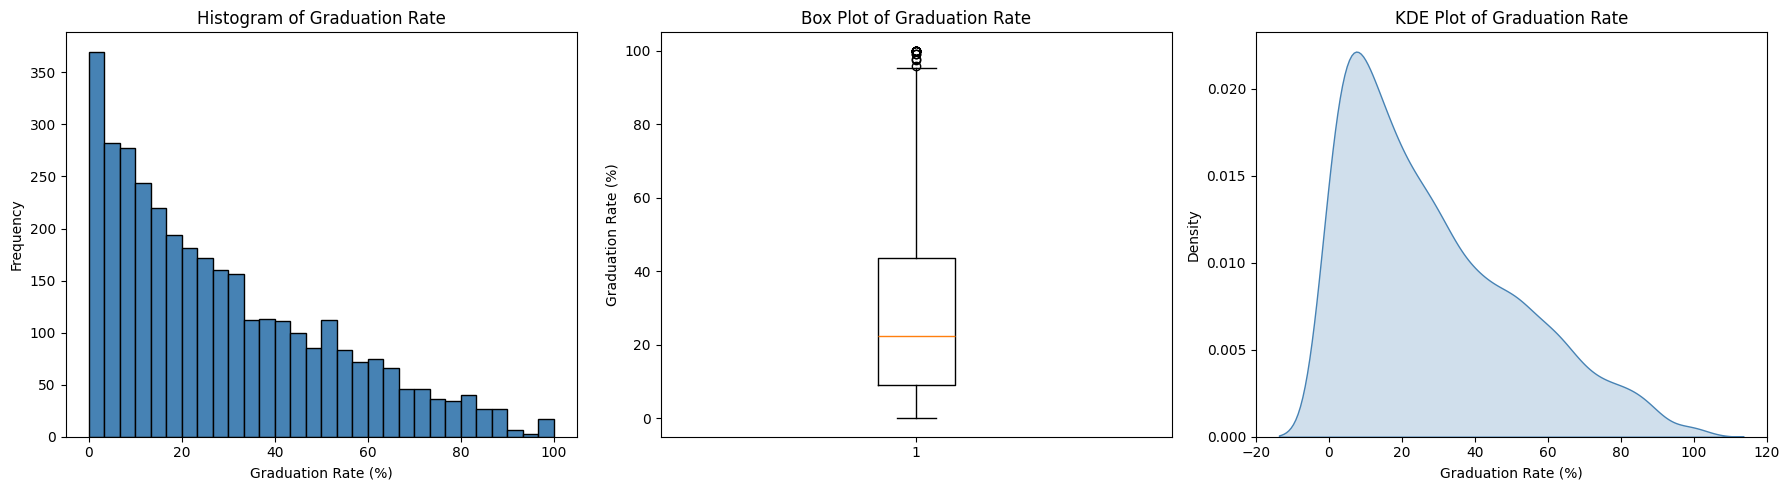

In [29]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['grad_100_value'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Graduation Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Graduation Rate')

axes[1].boxplot(df['grad_100_value'].dropna())
axes[1].set_ylabel('Graduation Rate (%)')
axes[1].set_title('Box Plot of Graduation Rate')

sns.kdeplot(df['grad_100_value'].dropna(), ax=axes[2], fill=True, color='steelblue')
axes[2].set_xlabel('Graduation Rate (%)')
axes[2].set_ylabel('Density')
axes[2].set_title('KDE Plot of Graduation Rate')

plt.tight_layout()
plt.show()

<!-- Edited -->
**Q1.7 (1 Point)**: For the `grad_100_value` variable, create a Kernel Density Plot that is grouped by `control`. Based on this plot, what type of `control` seems to have the best (highest) graduation rates?

**Answer Here**: private not for profit schools have the highest graduation rates. The distribution for this class is furthest right

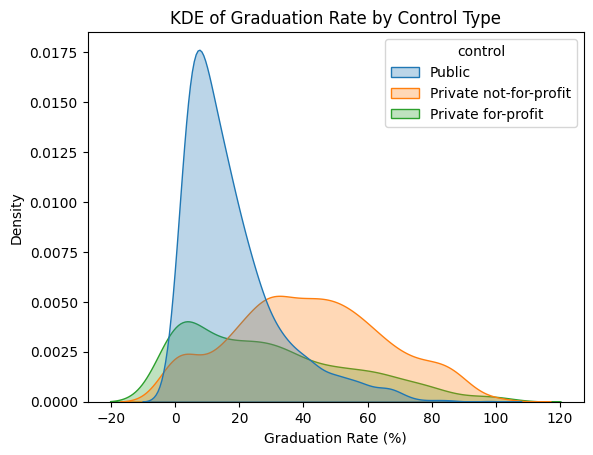

In [30]:

sns.kdeplot(data=df.dropna(subset=['grad_100_value']), x='grad_100_value', hue='control', fill=True, alpha=0.3)
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Density')
plt.title('KDE of Graduation Rate by Control Type')
plt.show()

<!-- Edited -->
**Q1.8 (1 Point)**: For the `grad_100_value` variable, create a Kernel Density Plot that is grouped by `level`. Based on the plot, what `level` (4-year or 2-year) seems to have the highest graduation rates?

**Answer Here:** 4 year institutions have a higher graduation rate than 2 years.

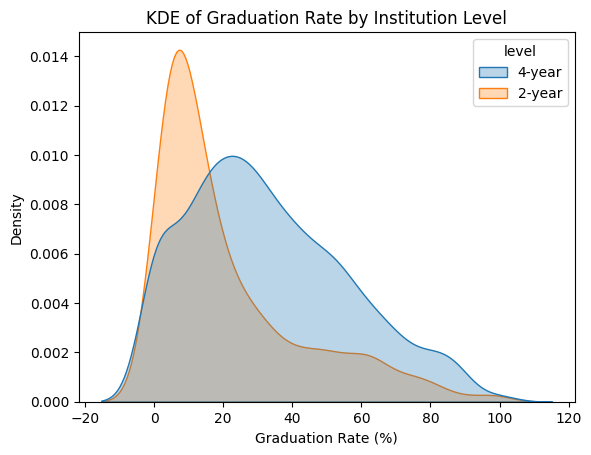

In [31]:
sns.kdeplot(data=df.dropna(subset=['grad_100_value']), x='grad_100_value', hue='level', fill=True, alpha=0.3)
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Density')
plt.title('KDE of Graduation Rate by Institution Level')
plt.show()

**Q1.9 (1 Point)**: Generate the grouped statistical descriptions of `grad_100_value` by `level`.
  - (Hint: use `.describe()` and `.groupby()`)

In [32]:
df.groupby('level')['grad_100_value'].describe()

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
2-year,1455.0,21.636151,21.645747,0.0,6.0,13.0,30.600,100.0
4-year,2012.0,33.230119,23.270160,0.0,15.2,29.7,49.225,100.0


**Q1.10 (1 Point)**: Generate the grouped statistical descriptions of `grad_100_value` by `control`.
  - (Hint: use `.describe()` and `.groupby()`)

In [33]:
df.groupby('control')['grad_100_value'].describe()

,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


<!-- Edited -->
**Q1.11 (2 Points)**:
  - Using your grouped descriptions, which `level` of institutions has the highest average graduation rates?
  - Which type of `control` has the highest average graduation rate?

**Answer:** 
- **Level**: 4-year institutions have the highest average graduation rates.
- **Control**: Private not-for-profit institutions have the highest average graduation rate.,

<!-- Edited -->
**Q1.12 (1 Point)**: Does your answer to **Q1.11** agree with your answers from **Q1.7** and **Q1.8**?

**Answer:** Yes, they both have the same results for both control and level.

<!-- Edited -->
**Q1.13 (2 Points)**:

1. Create a new variable, `df['levelXcontrol']=df['level']+', '+df['control']` that interacts `level` and `control`.

1. Make a grouped kernel density plot of `grad_100_value` grouped by the new variable you created.

1. Add reasonable labels for the x-axis, title, and legend of your grouped KDE Plot. *Hint:* You can change the legend title as an argument in the `sns.move_legend()` function. Look at the documentation for `sns.move_legend()`.

1. Generate the grouped statistical descriptions of `grad_100_value` grouped by your new variable.

1. From your visualization and statistical descriptions, which institutions (combination of level and control) appear to have the best graduation rates? Which combination has the worst graduation rates?

**Answer:** 4 year private not-for-profit institutions have the best graduation rates, and 2-year public has the worst.

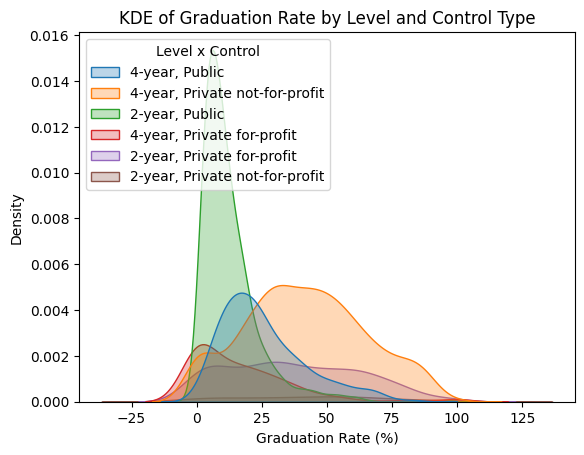

,count,mean,std,min,25%,50%,75%,max
levelXcontrol,,,,,,,,
"2-year, Private for-profit",461.0,37.197614,25.497380,0.0,15.800,33.9,57.800,100.0
"2-year, Private not-for-profit",68.0,41.913235,28.348302,0.0,16.225,44.4,61.200,100.0
"2-year, Public",926.0,12.400000,10.893600,0.0,5.100,9.4,16.175,97.8
"4-year, Private for-profit",318.0,17.382704,20.788525,0.0,0.000,12.5,26.325,100.0
"4-year, Private not-for-profit",1121.0,41.645674,23.243453,0.0,25.000,41.0,57.800,100.0
"4-year, Public",573.0,25.561082,16.403902,0.0,13.600,21.8,33.800,86.3


In [34]:
df['levelXcontrol'] = df['level'] + ', ' + df['control']

sns.kdeplot(data=df.dropna(subset=['grad_100_value']), x='grad_100_value', hue='levelXcontrol', fill=True, alpha=0.3)
plt.xlabel('Graduation Rate (%)')
plt.title('KDE of Graduation Rate by Level and Control Type')
sns.move_legend(plt.gca(), "upper left", title='Level x Control')
plt.show()

df.groupby('levelXcontrol')['grad_100_value'].describe()

**Q1.14 (1 Point)**: Create a scatterplot of the `grad_100_value` variable and `aid_value`. Place `aid_value` on the x-axis and `grad_100_value` on the y-axis. Add reasonable labels for the x-axis, y-axis, and title.

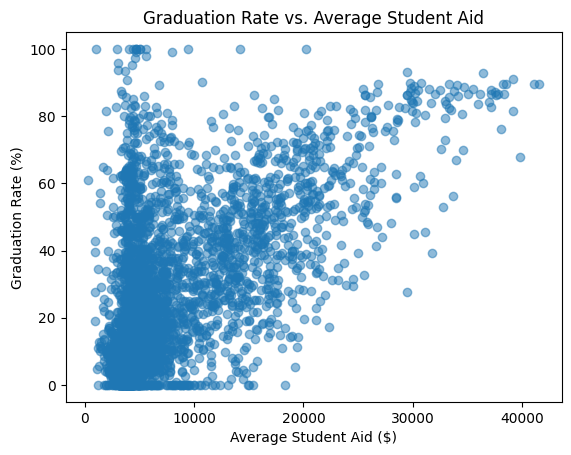

In [35]:
plt.scatter(df['aid_value'], df['grad_100_value'], alpha=0.5)
plt.xlabel('Average Student Aid ($)')
plt.ylabel('Graduation Rate (%)')
plt.title('Graduation Rate vs. Average Student Aid')
plt.show()

**Q1.15 (2 Points)**: Calculate the covariance and correlation matrix between `grad_100_value` and `aid_value`.

In [36]:
subset = df[['grad_100_value', 'aid_value']].dropna()
print("Covariance Matrix:")
print(subset.cov())
print("\nCorrelation Matrix:")
print(subset.corr())

Covariance Matrix:
                grad_100_value     aid_value
grad_100_value      543.211540  8.861048e+04
aid_value         88610.483169  4.358513e+07

Correlation Matrix:
                grad_100_value  aid_value
grad_100_value        1.000000   0.575879
aid_value             0.575879   1.000000


<!-- Edited -->
**Q1.16 (1 Point)**:
  - From the scatterplot and matrices you created, what relationship do you see?
  - Is there a positive or negative relationship between the two variables?
  - How strong is it? Hint: Look at the correlation value for sign and strength.

**Answer:** there is a positive relationship between aid_value and grad_100_value. It is moderate in strength (~0.5).

**Q1.17 (1 Point)**: Re-create your scatter plot of `grad_100_value` and `aid_value`. This time, change the color of the points based on the `control` variable. For which kinds of institutions does aid seem to have the strongest correlation with graduation rates?

**Answer:** private not for profit has the strongest positive correlation

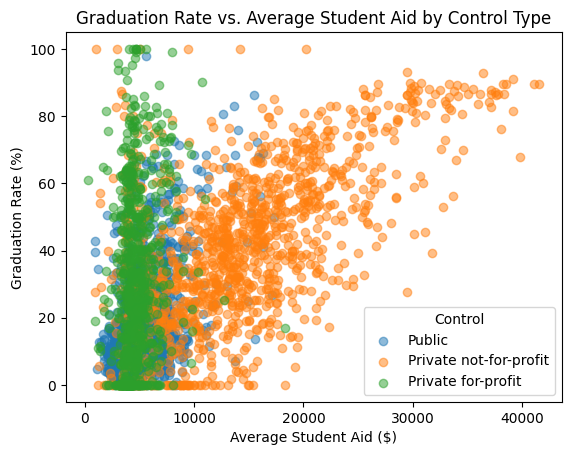

In [37]:

for control_type in df['control'].dropna().unique():
    mask = df['control'] == control_type
    plt.scatter(df.loc[mask, 'aid_value'], df.loc[mask, 'grad_100_value'], alpha=0.5, label=control_type)
plt.xlabel('Average Student Aid ($)')
plt.ylabel('Graduation Rate (%)')
plt.title('Graduation Rate vs. Average Student Aid by Control Type')
plt.legend(title='Control')
plt.show()

## Section 2: K Nearest Neighbors (60 Points Total)

### Question 2

<!-- Edited -->
**Q2.1 (2 Points)**: What is the difference between regression and classification?

**Answer:** regression and classification are used on two different data types. regression tries to predict a pattern to interpolate, while classification labels categorical data. e.g. regression = linear regression as a linear function, classification = is it a car or a bird?

<!-- Edited -->
**Q2.2 (2 Points)**: What is a confusion table? What does it help us understand about a model's performance?

**Answer:** The confusion matrix is a visual representation of the performance of a model, in terms of its errors. The entries of a confusion matrix are each type of possible failure in prediction (predicted != ground truth) and show the count for each alongside the correct predictions. It helps us see the error in the model.

<!-- Edited -->
**Q2.3 (2 Points)**: What does the SSE quantify about a particular model?

**Answer:** The sum fo squared errors quantifies the total difference between the predicted values and the ground true observed values.

<!-- Edited -->
**Q2.4 (2 Points)**: What are overfitting and underfitting?

**Answer:** **Overfitting** Overfitting is when a model is trained to predict too perfectly on a given training data set by over-using certain features in the training data set. that is, it overemphasises features and values that are explicitly only uncovered within the training dataset, and consequently are not applicable to data during usage. Because of this, the model exhibits an extremely high accuracy on the given training dataset but begins to fail on data outside of it. Underfitting is the opposite case, where a model does not learn the features of the data set enough and is too generalised, causing poor performance.

<!-- Edited -->
**Q2.5 (2 Points)**: Why does splitting the data into training and testing sets, and choosing by evaluating accuracy or SSE on the test set, improve model performance?

**Answer:** Splitting the data allows for evaulation on how well the mdoel generalises on unseen data. By only training on the training data, the model is able to use the resulting performance metrics found by testing on the testing data in order to ensure that the model accurately generalises to the larger data context, keeping from being overfit or underfit. The unbiased estimate on the model's performance during testing can be optimised for the best possible performance using the sse/accuracy results.

<!-- Edited -->
**Q2.6 (2 Points)**: With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain potential strengths and weaknesses of each approach.

**Answer:**

**Predicting a class label:**
- *Strengths*: simple, easy to interpret, more useful
- *Weaknesses*: removes uncertainty information, not good when most datapoints don't have a clear prediction result (i.e. probability distribution is always pretty uncertain)

**Predicting a probability distribution:**
- *Strengths*: preserves uncertatinty information, can use extra informatino for further interpretaion or usage within the mdoel
- *Weaknesses*: harder to interpret and communicate to external stakeholders.

### Question 3

For this question, you will create a $k$ nearest neighbor regression model for the `USA_cars_datasets.csv` data. The data can be found on the GitHub repository for the class in the `assignments/data/` folder. The target variable `y` is `price` and the features are `year` and `mileage`.

**Q3.1 (2 Points)**:

- Load the `USA_cars_datasets.csv` data set. Call the data frame `cars_df`.
- Keep the following variables and drop the rest: `price`, `year`, `mileage`.
- Look at the data using head and report the dimensions (num rows, num columns) of the data. Print both values to the screen.
- Are there any `NA`'s to handle? Include your answer as comment in your code near where you answer this question.

In [38]:
cars_df = pd.read_csv('data/USA_cars_datasets.csv')
cars_df = cars_df[['price', 'year', 'mileage']]
print(f"Dimensions: {cars_df.shape[0]} rows, {cars_df.shape[1]} columns")
print(cars_df.isna().sum())
cars_df.head()
# No NAs present in the price, year, or mileage columns

Dimensions: 2499 rows, 3 columns
price      0
year       0
mileage    0
dtype: int64


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


**Q3.2 (2 Points)**:  MaxMin normalize the `year` and `mileage` variables. First create them as columns in the `cars_df` data frame. Next, isolate these scaled columns in a new data frame called `X`.

In [39]:

cars_df['year_scaled'] = (cars_df['year'] - cars_df['year'].min()) / (cars_df['year'].max() - cars_df['year'].min())
cars_df['mileage_scaled'] = (cars_df['mileage'] - cars_df['mileage'].min()) / (cars_df['mileage'].max() - cars_df['mileage'].min())
X = cars_df[['year_scaled', 'mileage_scaled']]
X.head()

,year_scaled,mileage_scaled
0,0.744681,0.269287
1,0.808511,0.187194
2,0.957447,0.038892
3,0.872340,0.063016
4,0.957447,0.006537


**Q3.3 (2 Point)**: Split your data set into a 70/30 split, where 70% of the data are in the training data set and 30% are in the test data set. Use a random state seed of `100` for replicability.

In [40]:

from sklearn.model_selection import train_test_split

y = cars_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1749
Test set size: 750


**Q3.4 (5 Points)**:

- Train a KNN model using your training data to predict predict `price` using `year` and `mileage`. Investigate the following values of $k$: $k=3,10,25,50,100,300$.

- For each value of $k$, compute the mean squared error for the train and test data and save these values in a list for later.

- As well, for each value of $k$ create a scatterplot showing the true value of `price` in the **test** dataset against the predicted value of `price`.
  - In the title for each plot, inlcude the value of k and the calculated MSE.
  - Set the ylimit and xlimit for each plot to be between [-100, 62000]. You can do this using `plt.xlim([-100, 62000])` and `plt.ylim([-100, 62000])` after you have created the scatter plot.
  - Make sure to use `plt.show()` each time you are done creating a plot for that value of $k$.

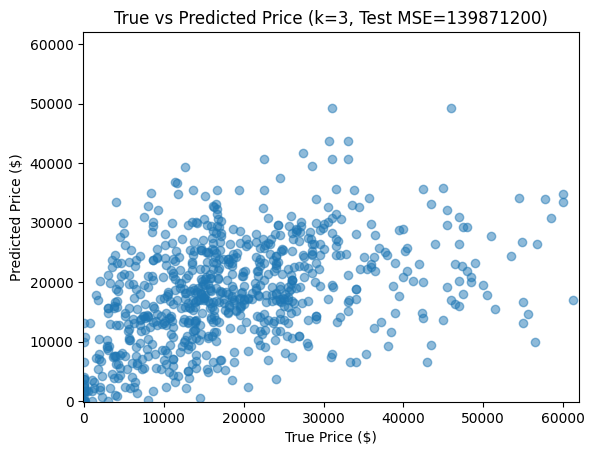

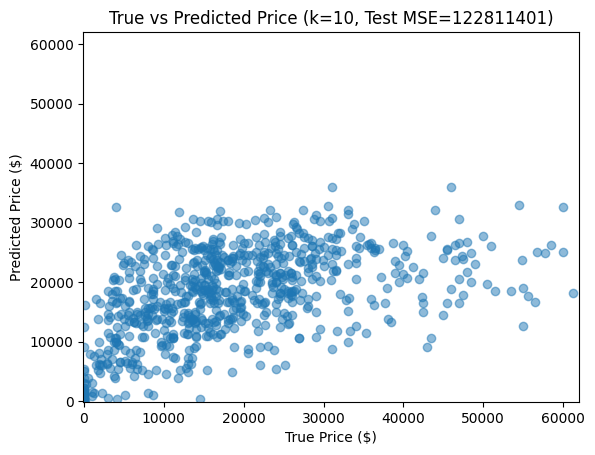

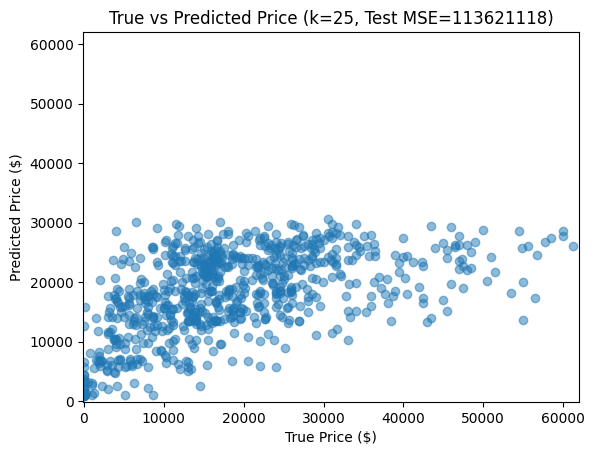

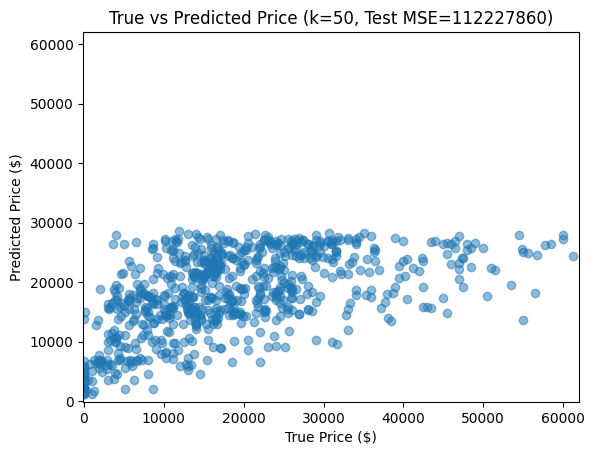

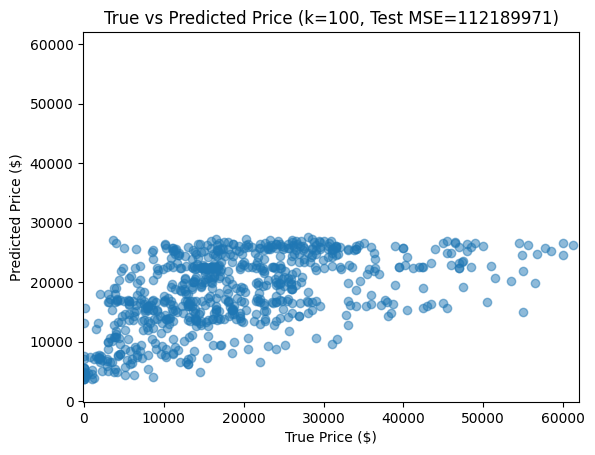

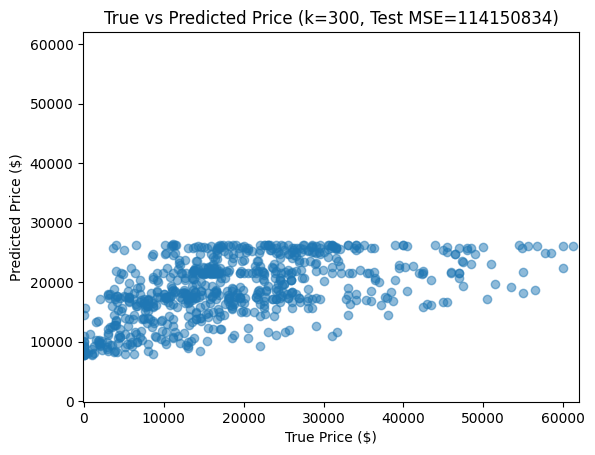

In [41]:

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3, 10, 25, 50, 100, 300]
train_mse_list = []
test_mse_list = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.xlabel('True Price ($)')
    plt.ylabel('Predicted Price ($)')
    plt.title(f'True vs Predicted Price (k={k}, Test MSE={test_mse:.0f})')
    plt.xlim([-100, 62000])
    plt.ylim([-100, 62000])
    plt.show()


**Q3.5 (2 Points)**: From the generated plots above, what patterns do you notice as you increase the value of $k$? Hint: what happens to our predictions?

**Answer:** as k increase, the scatter plot becomes increasingly compressed toward a narrow range of values. that is, our model approaches predicting all data inputs as closer to the same output. it converges to the mean of the training prices and reduces accuracy

<!-- Edited -->
**Q3.6 (3 Points)**: Using your saved values of the MSE for the train and test data, plot both as line plots for different values of k. What does this plot show?

**Answer:** it shows the bias variance tradeoff with k. at smaller valuesof k, the train mse is low and test is high (extreme overfitting). as k increases, the overfitting reduces until a certain point where underfitting begins to occur.

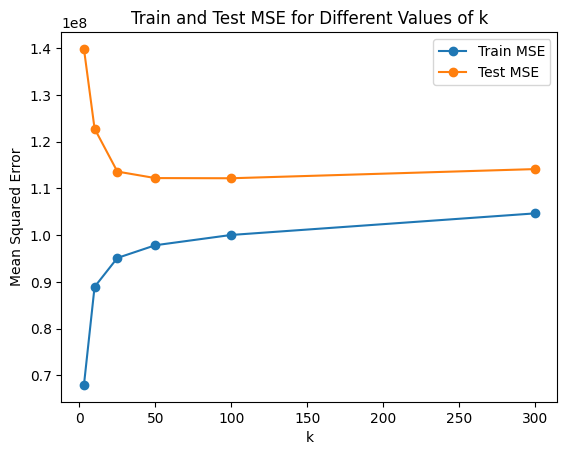

In [42]:

plt.plot(k_values, train_mse_list, label='Train MSE', marker='o')
plt.plot(k_values, test_mse_list, label='Test MSE', marker='o')
plt.xlabel('k')
plt.ylabel('Mean Squared Error')
plt.title('Train and Test MSE for Different Values of k')
plt.legend()
plt.show()

<!-- Edited -->
**Q3.7 (2 Points)**
  - What is the optimal value of $k$ from the $k$'s the we have investigated? Create a variable `best_k` that stores the best value of k and print it to the screen.
  - Which subset of data did you use to determine the optimal value of $k$?

**Answer:** th eoptimal value of k from our tested set is the one that minimizes the test mse. you use the test set to determine the best k value. our best k in this case is k=100

In [43]:

best_k = k_values[test_mse_list.index(min(test_mse_list))]
print(f"Best k: {best_k}")

Best k: 100


**Q3.8 (5 Points)** Repeat the process from **Q3.4**. This time, investigate all possible values of k from 1 to 200.
  - Do **NOT** make plots of the predicted vs actual values.
  - Do make a plot that shows the train and test MSE for each value of $k$ this time. (MSE on the y-axis and $k$ on the x-axis.)
  - Identify the best value of k from this new set of all possible values of $k$. Again, print the best value of to the screen.

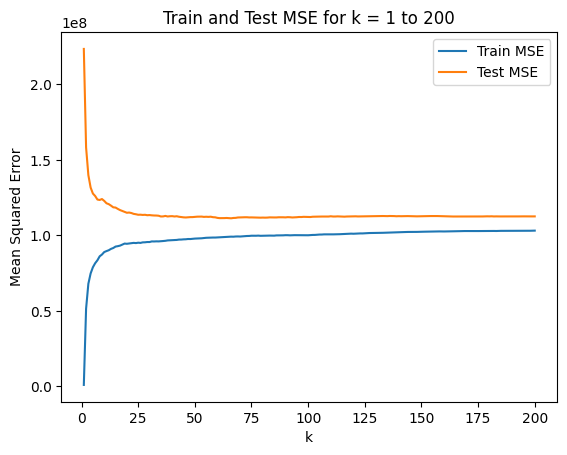

Best k (from k=1 to 200): 66


In [44]:

k_range = range(1, 201)
train_mse_all = []
test_mse_all = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_mse_all.append(mean_squared_error(y_train, knn.predict(X_train)))
    test_mse_all.append(mean_squared_error(y_test, knn.predict(X_test)))

plt.plot(k_range, train_mse_all, label='Train MSE')
plt.plot(k_range, test_mse_all, label='Test MSE')
plt.xlabel('k')
plt.ylabel('Mean Squared Error')
plt.title('Train and Test MSE for k = 1 to 200')
plt.legend()
plt.show()

best_k_full = list(k_range)[test_mse_all.index(min(test_mse_all))]
print(f"Best k (from k=1 to 200): {best_k_full}")

<!-- Edited -->
**Q3.9 (2 Points)**: Now that we know how the model is performing across different values of $k$, revisit the plots that you created in **Q3.5**.
   - Describe what happened in the plots of predicted versus actual prices in the test set as $k$ varied (Hint: Use the words "underfitting" and "overfitting".)

**Answer:** at small values of k, the model is overfitting. the model learns the training data too closely and ends up failing when presented with unseen data. this is shown in our graph, where predicted vs actual is very erratic in test and has a high test mse. As k increases to larger values (>100) the model begins to underfit. that is, it averages the feature values too much and begins generalisign to a point that the model no longer provides any meaningful data. because of this, it predicts all the various test data to be closer to the same value (in this case ~30000)

### Question 4

This is a case study on $k$ nearest neighbor classification, using the `zoo.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

**Q4.1 (2 Points)**: Load the data as data frame: `zoo_df`.
  - `For` each of the seven `class` labels, print the unique `animal` values in that class.
  - This will help you get a sense of what is included in that group.






In [45]:

zoo_df = pd.read_csv('data/zoo.csv')
for class_label in sorted(zoo_df['class'].unique()):
    animals = zoo_df[zoo_df['class'] == class_label]['animal'].values
    print(f"Class {class_label} (count: {len(animals)}): {list(animals)}")

Class 1 (count: 41): ['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'dolphin', 'elephant', 'fruitbat', 'giraffe', 'girl', 'goat', 'gorilla', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'porpoise', 'puma', 'pussycat', 'raccoon', 'reindeer', 'seal', 'sealion', 'squirrel', 'vampire', 'vole', 'wallaby', 'wolf']
Class 2 (count: 20): ['chicken', 'crow', 'dove', 'duck', 'flamingo', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vulture', 'wren']
Class 3 (count: 5): ['pitviper', 'seasnake', 'slowworm', 'tortoise', 'tuatara']
Class 4 (count: 13): ['bass', 'carp', 'catfish', 'chub', 'dogfish', 'haddock', 'herring', 'pike', 'piranha', 'seahorse', 'sole', 'stingray', 'tuna']
Class 5 (count: 4): ['frog', 'frog', 'newt', 'toad']
Class 6 (count: 8): ['flea', 'gnat', 'honeybee', 'housefly', 'ladybird', 'mot

<!-- Edited -->
**Q4.2 (2 Points)**: Additional EDA:
  - How many observations are there for each of the `class` values?
  - If you make a histogram, how many bins should you use?
  - Does it look like there's an even split among the classes?

**Answer:** 
class 1 mammals - 41 (most)


Based on the value counts, the classes have different numbers of observations — class 1 (mammals) has the most with 41 animals, while other classes like class 6 (insects) and class 7 (reptiles) have only a handful of observations each. For a histogram of 7 discrete class values, we should use **7 bins** to show one bar per class. The split is **not even** — the classes are imbalanced, with class 1 dominating and smaller classes being much less represented. This imbalance is important to keep in mind when building and evaluating a classifier.

Counts per class:
class
1    41
2    20
3     5
4    13
5     4
6     8
7    10
Name: count, dtype: int64


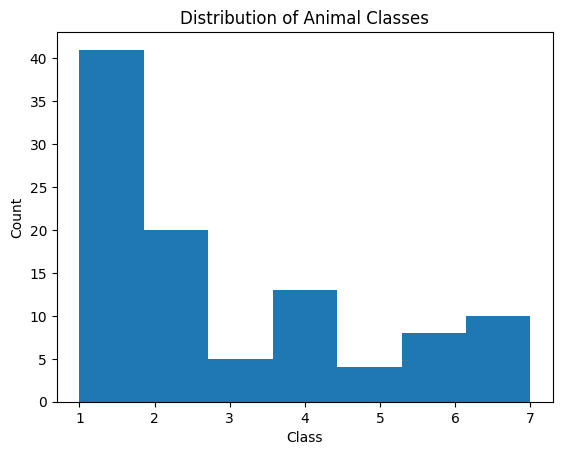

In [46]:

class_counts = zoo_df['class'].value_counts().sort_index()
print("Counts per class:")
print(class_counts)
n_bins = zoo_df['class'].nunique()
plt.hist(zoo_df['class'], bins=n_bins)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Animal Classes')
plt.show()

**Q4.3 (2 Points)**: Additional EDA:
  - How much variation is there in each of the features/covariates? Look at the distribution of any of the features you find interesting.
  - Visualize the distirbution of at least 2 features.

Feature statistics:
             hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
75%      1.000000    0.000000    1.000000    1.000000    0.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

         predator     toothed    backbone    breathes    venomous        fins  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.554455    0.603960    0.821782    0.792079    0.079208    0.168317   
std    

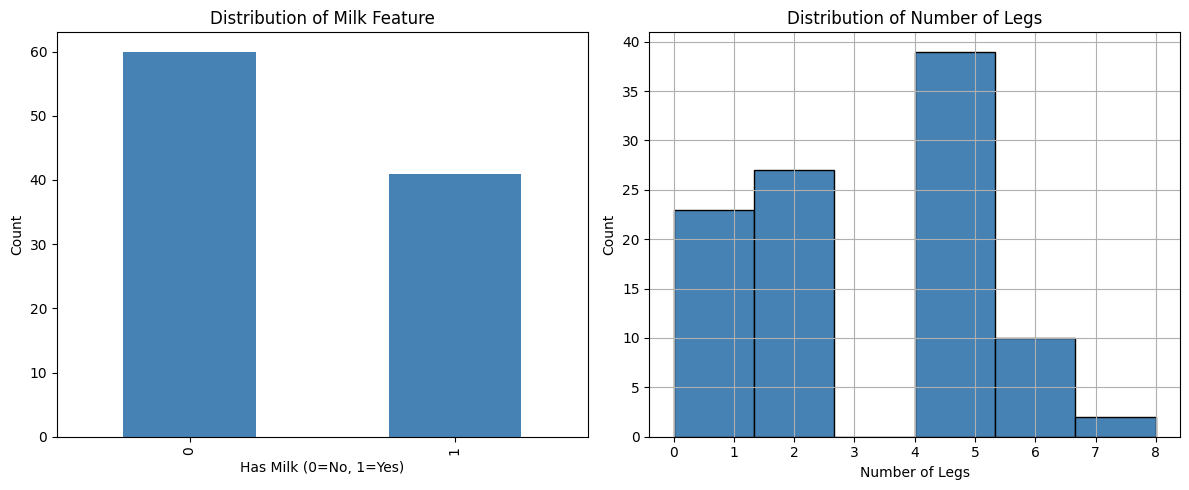

In [47]:

numeric_features = zoo_df.select_dtypes(include=[np.number]).columns.drop('class')
print("Feature statistics:")
print(zoo_df[numeric_features].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

zoo_df['milk'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Milk Feature')
axes[0].set_xlabel('Has Milk (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

zoo_df['legs'].hist(ax=axes[1], bins=6, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Number of Legs')
axes[1].set_xlabel('Number of Legs')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Q4.4 (2 Points)**: We want to predict the `class` for each observation using a KNN Classifier.
  - Split your data into your outcome (y) and features (X).
  - Remove any non-numeric data from your features.
  - Split the data 50/50 into training and test/validation sets. Use a random state of 10 for replicability. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

In [48]:

y_zoo = zoo_df['class']
X_zoo = zoo_df.select_dtypes(include=[np.number]).drop(columns=['class'])

X_zoo_train, X_zoo_test, y_zoo_train, y_zoo_test = train_test_split(X_zoo, y_zoo, test_size=0.5, random_state=10)
print(f"Training set size: {X_zoo_train.shape[0]}")
print(f"Test set size: {X_zoo_test.shape[0]}")

Training set size: 50
Test set size: 51



**Q4.5 (5 Points)**: Using all of the numeric variables, build a $k$-NN classifier.
  - Given your training data, what is the largest value of $k$ that you can test? Look at all values of $k$ from 1 to your identified max value.
  - From these values of $k$, identify the best value of $k$. How did you identify the best value of $k$?

**Answer:** the largest value k we can test is the size of the training set (~50), the best value is identified by the highest accuracy score on the test set. our best k = 1

Best k: 1
Best accuracy: 0.8824


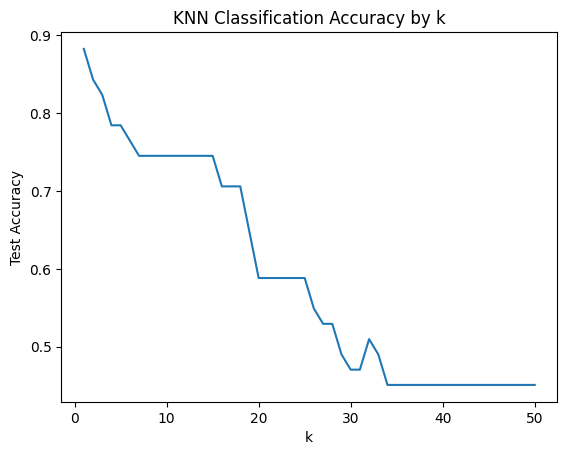

In [49]:

from sklearn.neighbors import KNeighborsClassifier

max_k_zoo = X_zoo_train.shape[0]
accuracies = []

for k in range(1, max_k_zoo + 1):
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_zoo_train, y_zoo_train)
    accuracies.append(knn_clf.score(X_zoo_test, y_zoo_test))

best_k_zoo = list(range(1, max_k_zoo + 1))[accuracies.index(max(accuracies))]
print(f"Best k: {best_k_zoo}")
print(f"Best accuracy: {max(accuracies):.4f}")

plt.plot(range(1, max_k_zoo + 1), accuracies)
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.title('KNN Classification Accuracy by k')
plt.show()


**Q4.6 (3 Points)**:
  - Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. Keep the table as raw counts.
  - How accurate is your optimal model?
  - Which true classes are we misclassifying?

**Answer:** our model is pretty accurate, with only a few errors, accuracy = 0.88. the largest error point was where we predicted 3 when actual was 1, with 3 total errors.others include class 3, 7

In [50]:
best_knn_clf = KNeighborsClassifier(n_neighbors=best_k_zoo)
best_knn_clf.fit(X_zoo_train, y_zoo_train)
y_zoo_pred = best_knn_clf.predict(X_zoo_test)

confusion = pd.crosstab(y_zoo_test, y_zoo_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Table:")
print(confusion)

accuracy = (y_zoo_pred == y_zoo_test).mean()
print(f"\nAccuracy: {accuracy:.4f}")

Confusion Table:
Predicted   1   2  3  4  5  6  7
Actual                          
1          20   0  0  3  0  0  0
2           0  10  0  0  0  0  0
3           1   0  1  0  1  0  0
4           0   0  0  6  0  0  0
5           0   0  0  0  2  0  0
6           0   0  0  0  0  2  0
7           0   0  0  0  1  0  4

Accuracy: 0.8824



**Q4.7 (5 Points)**: Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier.
  - Find the optimal model and print your confusion table for the optimal model.
  - Does your optimal model predict all possible classes? If not, what possible classes does it not predict?

**Answer:** it does not predict all classes. in our case, it does not predict classes 3,5,6,7.

In [ ]:

X_zoo_sub_train = X_zoo_train[['milk', 'aquatic', 'airborne']]
X_zoo_sub_test = X_zoo_test[['milk', 'aquatic', 'airborne']]

max_k_sub = X_zoo_sub_train.shape[0]
sub_accuracies = []

for k in range(1, max_k_sub + 1):
    knn_sub = KNeighborsClassifier(n_neighbors=k)
    knn_sub.fit(X_zoo_sub_train, y_zoo_train)
    sub_accuracies.append(knn_sub.score(X_zoo_sub_test, y_zoo_test))

best_k_sub = list(range(1, max_k_sub + 1))[sub_accuracies.index(max(sub_accuracies))]
print(f"Best k (subset): {best_k_sub}")

best_knn_sub = KNeighborsClassifier(n_neighbors=best_k_sub)
best_knn_sub.fit(X_zoo_sub_train, y_zoo_train)
y_zoo_sub_pred = best_knn_sub.predict(X_zoo_sub_test)

confusion_sub = pd.crosstab(y_zoo_test, y_zoo_sub_pred, rownames=['Actual'], colnames=['Predicted'])
print("\nConfusion Table (subset features):")
print(confusion_sub)

predicted_classes = set(y_zoo_sub_pred)
all_classes = set(zoo_df['class'].unique())
missing_classes = all_classes - predicted_classes
print(f"\nClasses not predicted: {missing_classes}")

Best k (subset): 12

Confusion Table (subset features):
Predicted   1  2  4
Actual             
1          23  0  0
2           0  9  1
3           0  3  0
4           0  0  6
5           0  0  2
6           0  2  0
7           0  1  4

Classes not predicted: {np.int64(3), np.int64(5), np.int64(6), np.int64(7)}



**Q4.8 (2 Points)** Using your optimal model, we want to know if it gives any chance to the classes that aren't being predicted right now.
  - To see the underlying probabilities for the test observations, use `model.predict_proba(X_test)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`.
  - Look at the plot that is created below. It is a heatmap where the class index is the columns and each row is an observation. The color indicates the probability that the model is assigning to a given class index.
  - Are all of the classes represented when we look at the probabilities instead of hard classifications? Explain your results.
  - Using this information, why might we want to look at the probabilities instead of the hard classification?

  **Answer:** all classes are represented in the probability distribution because there exists some non-zero probability values for all classes. We want to use probabilities in cases such as this when uncertainties may bring light other choices that a hard selection cannot.

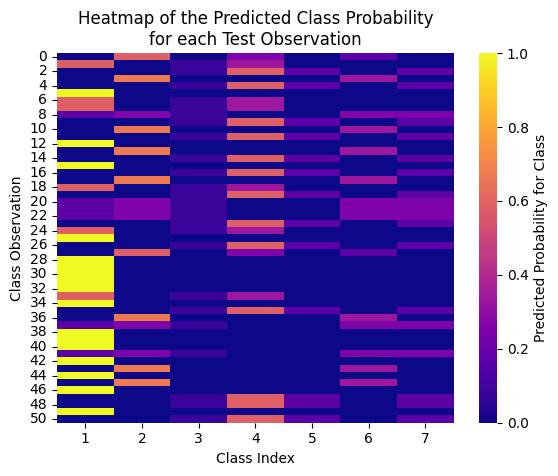

In [ ]:
predicted_proabilities = best_knn_sub.predict_proba(X_zoo_sub_test)

# Create a heatmap of the predicted probabilities per class
sns.heatmap(predicted_proabilities, cmap = 'plasma', cbar_kws={'label': 'Predicted Probability for Class'})
plt.xlabel('Class Index')
plt.ylabel('Class Observation')
plt.title('Heatmap of the Predicted Class Probability\nfor each Test Observation')
plt.xticks(np.arange(zoo_df['class'].unique().shape[0]) + 0.5, np.arange(zoo_df['class'].unique().shape[0]) + 1)
plt.show()

## Section 3: Clustering (15 Points Total)

### Question 5

For this question, we want to investigate how the K Means Clustering model performs as our data becomes either less or more noisey.

**Q5.0** Run the code below to create a function `createData`. This function will create data with 3 different clusters (i.e. data generation processes). This is done by changing the mean of the normal distribution. We can make the difference between the data sets less detectable by increasing the `noise` which is just the standard deviation of each distribution.

In [53]:
import numpy as np
import pandas as pd

# Creating a function that creates data with varying level of noise
# This noise is just the standard deviation
# This function returns a dataframe with the generated data

def createData(noise, N=50, seed = 100):
    # Set the seed for replicability
    np.random.seed(seed)

    # Generate (x1,x2,g) triples:
    X1 = np.array([
        np.random.normal(1,noise,N), # Group one has x with mean 1
        np.random.normal(1,noise,N)  # Group one has y with mean 1
    ])

    X2 = np.array([
        np.random.normal(3,noise,N), # Group two has x with mean 3
        np.random.normal(2,noise,N)  # Group two has x with mean 2
    ])

    X3 = np.array([
        np.random.normal(5,noise,N), # Group three has x with mean 5
        np.random.normal(3,noise,N)  # Group three has x with mean 3
    ])

    # Concatenate the data into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)

    # Retun the generate data
    return df

**Q5.1 (2 Point)**:  Using the `createData` function, create 5 data sets with varying levels of noise values. The values of noise and what you should call the data frames are included in the table below:

| Data Frame Name | Noise Value |
| --------------- | ----------- |
| `df0_125` | 0.125 |
| `df0_25` | 0.25 |
| `df0_5` | 0.5 |
| `df1_0` | 1.0 |
| `df2_0` | 2.0 |

In [ ]:
df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

<!-- Edited -->
**Q5.2 (2 Point)**:  Create scatter points of the `x1` and `x2` for each of your data sets and color the points based on the `group` variable.
  - For each plot, change the title so that it reflects what the value of noise is.
  - What do you notice happens to the visual distinctness of the clusters as you increase the noise level from 0.125 to 2?
  - When do the clusters begin to not be clear without the included coloring of the dots?

**Answer:** increasing the noise causes teh clusters to becom less visually distinct. they are no longer as clustered, and are more spread out. it becomes unclear at around ~0.5 noise. Any more than that and it becomes completely random

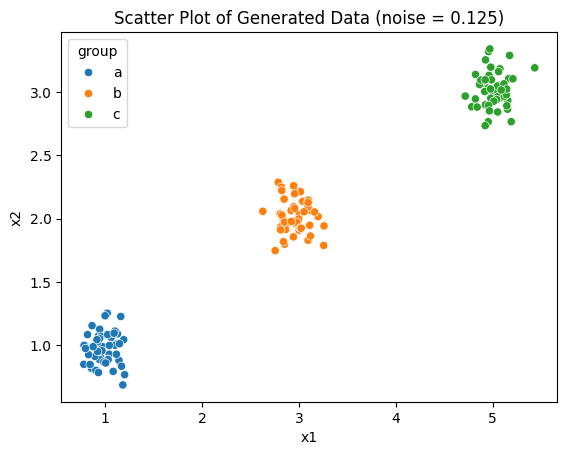

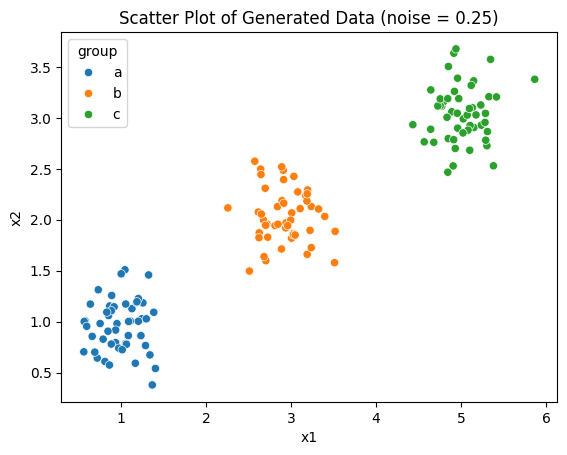

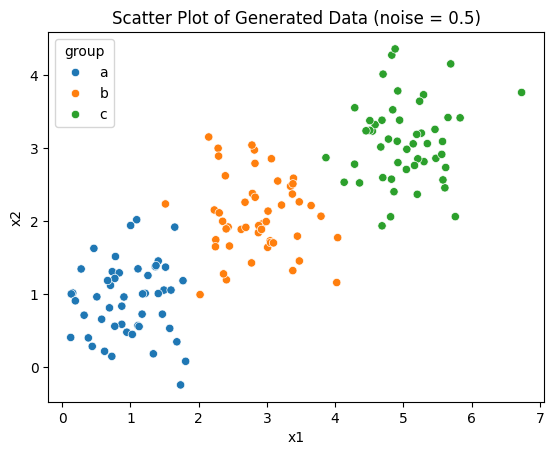

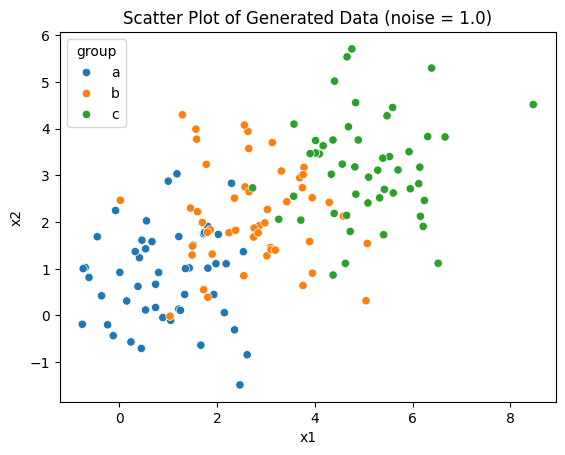

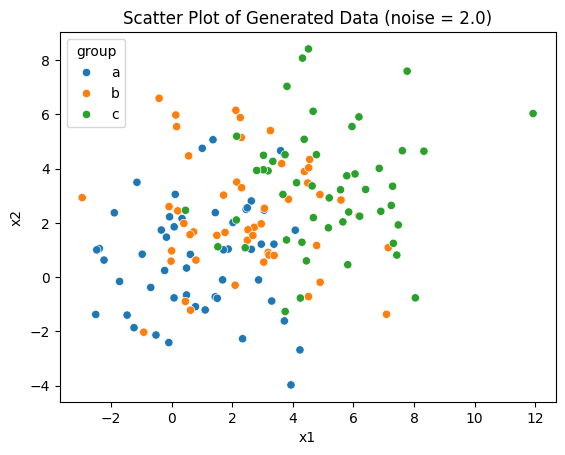

In [ ]:

datasets = [(df0_125, 0.125), (df0_25, 0.25), (df0_5, 0.5), (df1_0, 1.0), (df2_0, 2.0)]

for df_noise, noise in datasets:
    sns.scatterplot(data=df_noise, x='x1', y='x2', hue='group')
    plt.title(f'Scatter Plot of Generated Data (noise = {noise})')
    plt.show()

# Edited
from sklearn.cluster import KMeans

def GenerateScreePlot(data, noise):
    max_k = 15
    inertia_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data[['x1', 'x2']])
        inertia_values.append(kmeans.inertia_)

    plt.plot(range(1, max_k + 1), inertia_values, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster SSE)')
    plt.title(f'Scree Plot for K-Means Clustering (noise = {noise})')
    plt.ylim([0, max(inertia_values) * 1.1])
    plt.show()

for df_noise, noise in datasets:
    GenerateScreePlot(df_noise, noise)

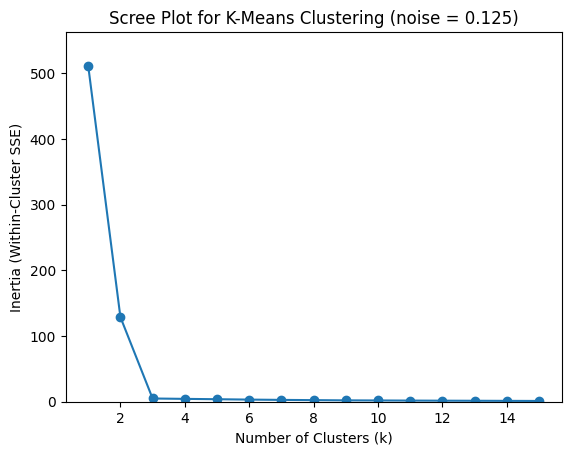

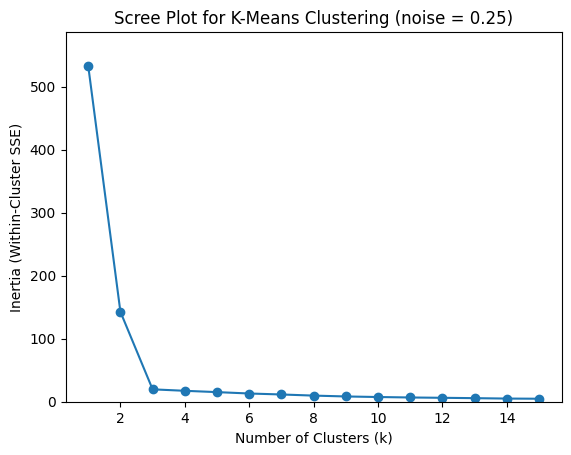

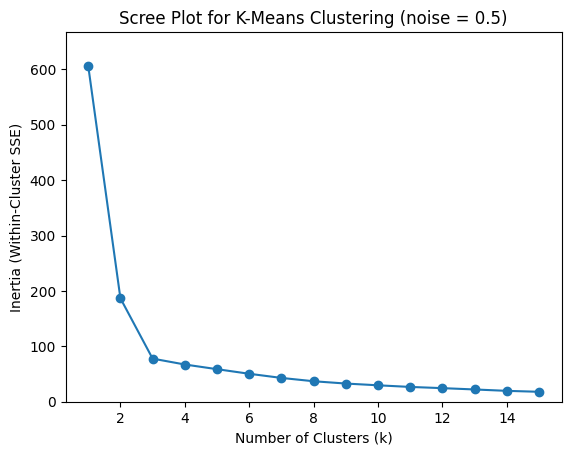

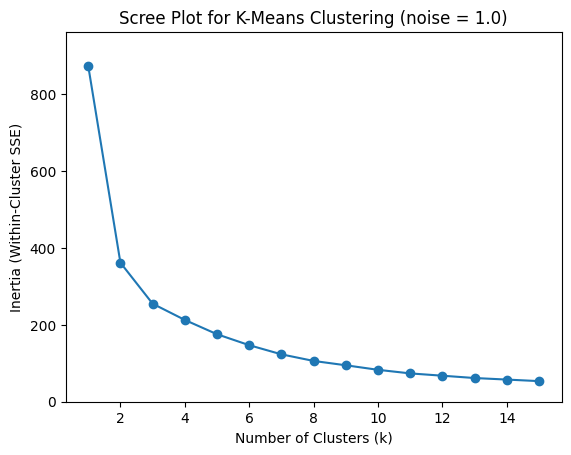

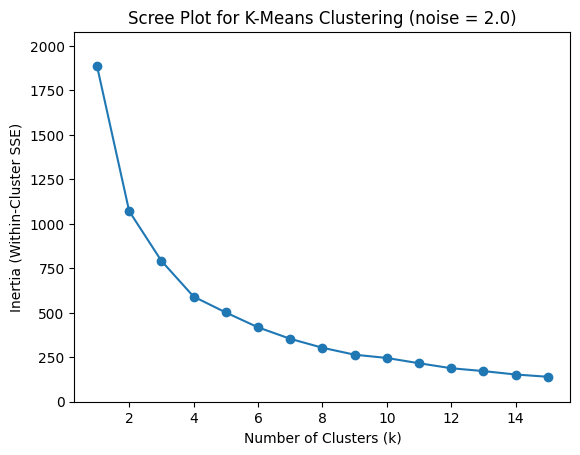

In [56]:
# Edited
from sklearn.cluster import KMeans

def GenerateScreePlot(data, noise):
    max_k = 15
    inertia_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data[['x1', 'x2']])
        inertia_values.append(kmeans.inertia_)

    plt.plot(range(1, max_k + 1), inertia_values, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster SSE)')
    plt.title(f'Scree Plot for K-Means Clustering (noise = {noise})')
    plt.ylim([0, max(inertia_values) * 1.1])
    plt.show()

for df_noise, noise in datasets:
    GenerateScreePlot(df_noise, noise)

**Q5.4 (2 Points)**:  
- From the plots you generated, what happens to the scree plot as the noise increases?
- What happens to your ability to identify the elbow, or optimal value of k, as the noise increases?

**Answer Here:** As noise increases, the scree pllt becomes more prononunced. with lower values, the graph is a lot sharper as it hits k=3, where it flattens out harder, with a clear elbow. With higher noise, it levels off less as k increases. The lower noise makes it easier to identify the correct k = 3.

it gets harder to find the elbow as noise increases past the optimal value

**Q5.5 (3 Point)**:  Given the example you ran, explain the intuition about using the elbow method with the scree plot. Discuss when the approach will work vs when it will not work.

**Answer:** The elbow method is based on the intuition that inertia reduction has diminishing returns. given a value j that represents the true number of clusters in our data. The scree plot allows us to easily determine this j value for our k with this elbow. 

This works best when our data is clearly separated and is actually clustered (low noise). 

it does not work if noise in our data is high and clusters heavily overlap or when j is very large, causing the elbow to be less distinct.